# Project: Multiple Linear Regression Diagnostics (Student Version)

This notebook is part of the course project on multiple linear regression and model diagnostics.

Dataset: `project_regression_diagnostics_data.csv` (generated for this project).

Constraints:
- Do not change the dataset.
- Save key results (tables/metrics) to CSV files.
- Use clear visualizations.
- Fill in the TODO sections.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad
from statsmodels.stats.outliers_influence import variance_inflation_factor

from pathlib import Path

DATA_PATH = Path("project_regression_diagnostics_data.csv")
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)


In [2]:
df = pd.read_csv(DATA_PATH)
df.head()


,time,y,x1,x2,x3,x4,x5
0,0,0.412070,0.001230,0.014572,-0.607621,0.099998,0.925033
1,1,1.620619,0.298746,0.556738,-0.742434,-0.725000,-0.972077
2,2,3.005629,-0.274138,-0.058808,-0.058650,-0.506993,1.967465
3,3,1.691503,-0.890592,-0.743848,-1.043304,-0.352615,0.879737
4,4,5.607247,-0.454671,-0.783301,0.606107,-0.219823,-0.304990


## Part 1: Exploratory Data Analysis

In [3]:
# Basic info
df.describe(include="all")


,time,y,x1,x2,x3,x4,x5
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,129.500000,2.990273,-0.163999,-0.184389,-0.029114,-0.029225,0.100323
std,75.199734,2.688506,0.920207,0.899150,0.953680,0.999771,1.168247
min,0.000000,-7.971777,-3.251438,-3.020742,-2.760418,-2.836852,-1.997373
25%,64.750000,1.271778,-0.793633,-0.735947,-0.608834,-0.632933,-0.830719
50%,129.500000,2.697819,-0.115156,-0.158301,-0.056102,-0.052522,0.088753
75%,194.250000,4.235920,0.463549,0.440858,0.569629,0.648300,1.102200
max,259.000000,13.956897,2.244757,2.350041,2.532306,2.630197,1.997724


In [4]:
# Pairwise correlations
corr = df.drop(columns=["time"]).corr(numeric_only=True)
corr


,y,x1,x2,x3,x4,x5
y,1.000000,0.225973,0.161863,0.328948,0.256529,0.400890
x1,0.225973,1.000000,0.928470,0.073686,0.078544,-0.087677
x2,0.161863,0.928470,1.000000,0.060864,0.077632,-0.053437
x3,0.328948,0.073686,0.060864,1.000000,0.753609,0.007561
x4,0.256529,0.078544,0.077632,0.753609,1.000000,-0.006854
x5,0.400890,-0.087677,-0.053437,0.007561,-0.006854,1.000000


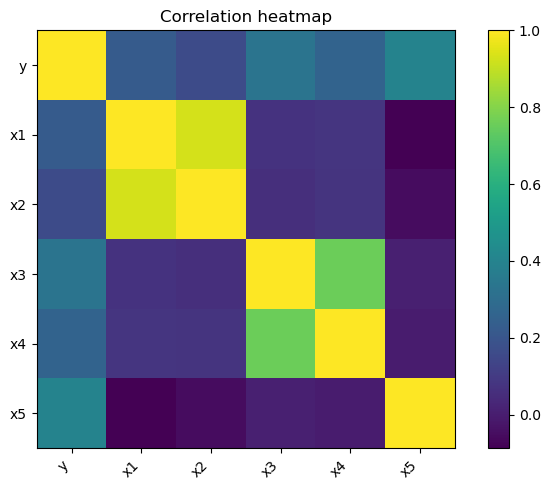

In [5]:
# Correlation heatmap (no seaborn)
plt.figure(figsize=(7,5))
plt.imshow(corr.values)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()


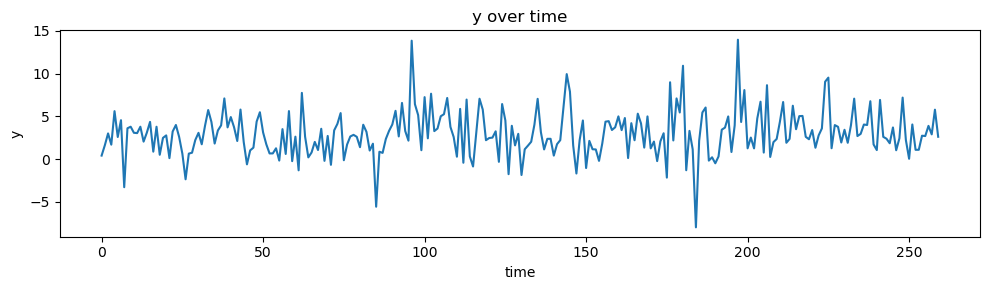

In [6]:
# Time series view of y
plt.figure(figsize=(10,3))
plt.plot(df["time"], df["y"])
plt.title("y over time")
plt.xlabel("time")
plt.ylabel("y")
plt.tight_layout()
plt.show()


## Part 2: Baseline model fit

# Baseline OLS model
# We start with a standard multiple linear regression:
# y ~ x1 + x2 + x3 + x4 + x5


In [7]:
model = smf.ols("y ~ x1 + x2 + x3 + x4 + x5", data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     27.14
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           5.68e-22
Time:                        14:45:20   Log-Likelihood:                -569.92
No. Observations:                 260   AIC:                             1152.
Df Residuals:                     254   BIC:                             1173.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9866      0.139     21.442      0.0

## Answer the following questions by interpreting the results and explaining the statistical concepts, assumptions, and implications of the methods used in this part. Avoid including code or raw outputs unless explicitly requested.

### 1. Based on the regression output, which predictors are statistically significant at the 5% significance level? Justify your answer.

### 2. Explain the difference between R-squared and Adjusted R-squared. Why is Adjusted R-squared generally preferred in multiple regression?

### 3. Explain the difference between interpreting a regression coefficient in a multiple regression model and interpreting a simple correlation coefficient.

### 1

بر اساس خروجی جدول رگرسیون، متغیرهای **x1**، **x2**، **x3** و **x5** (و همچنین عرض از مبدأ) در سطح خطای ۵٪ از نظر آماری معنادار هستند، زیرا مقدار p-value برای تمام این متغیرها کمتر از ۰.۰۵ است (برای x1، x3 و x5 برابر با ۰.۰۰۰ و برای x2 برابر با ۰.۰۰۲). در مقابل، متغیر **x4** با داشتن p-value برابر با ۰.۷۰۰ معنادار نیست و نمی‌توان اثر آن را متمایز از صفر دانست.

### 2

معیار R-squared تنها نشان می‌دهد چه درصدی از واریانس متغیر وابسته توسط مدل توجیه می‌شود، اما ایراد آن این است که با اضافه کردن هر متغیر جدید (حتی متغیرهای بی‌ربط) مقدارش افزایش می‌یابد. در رگرسیون چندمتغیره، Adjusted R-squared ترجیح داده می‌شود زیرا با اعمال جریمه برای تعداد متغیرها، تنها زمانی افزایش می‌یابد که متغیر جدید واقعاً کیفیت مدل را بهبود بخشد و بدین ترتیب از انتخاب مدل‌های پیچیده و دچار بیش‌برازش (Overfitting) جلوگیری می‌کند.

### 3

ضریب همبستگی ساده تنها شدت رابطه خطی بین دو متغیر را به صورت ایزوله و بدون در نظر گرفتن سایر عوامل می‌سنجد. در مقابل، ضریب رگرسیون در مدل چندمتغیره، میزان تغییر مورد انتظار در متغیر وابسته به ازای یک واحد تغییر در آن متغیر خاص را نشان می‌دهد، **مشروط بر اینکه سایر متغیرهای مدل ثابت بمانند**. این ویژگی باعث می‌شود بتوانیم اثر خالص و جزئی هر متغیر را با کنترل کردن اثر سایر متغیرها بررسی کنیم.

## Part 3: ANOVA

# ANOVA table for the baseline model


In [8]:
anova_tbl = anova_lm(model, typ=2)
anova_tbl


,sum_sq,df,F,PR(>F)
x1,101.520726,1.0,21.132176,6.762198e-06
x2,45.335392,1.0,9.436846,2.358041e-03
x3,64.255603,1.0,13.375207,3.099281e-04
x4,0.716908,1.0,0.149229,6.995968e-01
x5,344.220083,1.0,71.651571,2.071418e-15
Residual,1220.237048,254.0,NaN,NaN


In [9]:
anova_tbl.to_csv(OUT_DIR / "anova_baseline.csv")


## Part 4: Linear contrasts

# Linear contrasts (tests of linear combinations of coefficients)
### 1) H0: x1 and x2 have equal effects -> beta_x1 - beta_x2 = 0
### 2) H0: x3 + x4 = 0
### 3) H0: x1 + x2 + x5 = 0


In [10]:
# 1) H0: x1 and x2 have equal effects -> x1 - x2 = 0
test_1 = model.t_test("x1 = x2")
print("Contrast 1 (x1 - x2 = 0):\n", test_1)

# 2) H0: x3 + x4 = 0
test_2 = model.t_test("x3 + x4 = 0")
print("\nContrast 2 (x3 + x4 = 0):\n", test_2)

# 3) H0: x1 + x2 + x5 = 0
test_3 = model.t_test("x1 + x2 + x5 = 0")
print("\nContrast 3 (x1 + x2 + x5 = 0):\n", test_3)


results_list = []

def extract_contrast_data(res, description):
    return {
        "Description": description,
        "Estimate": res.effect[0],
        "Std_Err": res.sd[0][0],
        "t_statistic": res.tvalue[0][0],
        "p_value": res.pvalue.item() 
    }

results_list.append(extract_contrast_data(test_1, "x1 - x2 = 0"))
results_list.append(extract_contrast_data(test_2, "x3 + x4 = 0"))
results_list.append(extract_contrast_data(test_3, "x1 + x2 + x5 = 0"))

df_contrasts = pd.DataFrame(results_list)
df_contrasts.to_csv(OUT_DIR / "linear_contrasts.csv", index=False)

df_contrasts

Contrast 1 (x1 - x2 = 0):
                              Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             3.1023      0.796      3.897      0.000       1.535       4.670

Contrast 2 (x3 + x4 = 0):
                              Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.8760      0.150      5.848      0.000       0.581       1.171

Contrast 3 (x1 + x2 + x5 = 0):
                              Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.5803      0.199      7.924

,Description,Estimate,Std_Err,t_statistic,p_value
0,x1 - x2 = 0,3.102328,0.796068,3.897064,1.246150e-04
1,x3 + x4 = 0,0.876014,0.149789,5.848311,1.521728e-08
2,x1 + x2 + x5 = 0,1.580282,0.199437,7.923699,7.256258e-14


## Answer the following questions by interpreting the results and explaining the statistical concepts, assumptions, and implications of the methods used in this part. Avoid including code or raw outputs unless explicitly requested.

### 1. Based on the results for the contrast x1 - x2 = 0, what conclusion can be drawn at the 5% significance level?

### 2. Why are linear contrasts more informative than individual t-tests in some applications?

### 3. Even when a contrast is statistically significant, what additional information should be considered before drawing practical conclusions?

### 1

نتایج نشان می‌دهد که مقدار P-value برای این آزمون (حدود ۰.۰۰۰) بسیار کمتر از سطح خطای ۰.۰۵ است. بنابراین، فرض صفر مبنی بر برابر بودن اثرات $x_1$ و $x_2$ رد می‌شود و نتیجه می‌گیریم که تفاوت آماری معناداری بین ضریب تأثیر این دو متغیر وجود دارد (اثر آن‌ها بر متغیر پاسخ یکسان نیست).

### 2

آزمون‌های t انفرادی معمولاً تنها نشان می‌دهند که آیا یک ضریب خاص مخالف صفر است یا خیر، اما تضادهای خطی (Linear Contrasts) به ما اجازه می‌دهند فرضیات پژوهشی خاص و پیچیده‌تری را بررسی کنیم (مانند آزمون برابری دو ضریب یا صفر بودن مجموع چند ضریب). این آزمون‌ها اطلاعاتی درباره روابط بین متغیرها می‌دهند که از بررسی جداگانه ضرایب به دست نمی‌آید.

### 3

معناداری آماری لزوماً به معنای اهمیت کاربردی نیست. پیش از نتیجه‌گیری نهایی، باید "اندازه اثر" (Effect Size) و "فواصل اطمینان" را بررسی کرد تا مشخص شود آیا مقدار اختلاف مشاهده‌شده در دنیای واقعی به اندازه‌ای بزرگ است که اهمیت داشته باشد یا خیر؛ همچنین باید هزینه‌ها و قابلیت اجرایی بودن نتایج را نیز در نظر گرفت.

## Part 5: Diagnostics

# Model diagnostics
# We check:
### - Independence of residuals (Durbin-Watson)
### - Normality of residuals (Q-Q plot + test)
### - Multicollinearity (VIF)
### - Outliers and influence (studentized residuals, leverage, Cook's distance)
### - Homoscedasticity (residual plots + Breusch-Pagan)


In [11]:
residuals = model.resid
fitted = model.fittedvalues

print("Residuals head:\n", residuals.head())
print("\nFitted values head:\n", fitted.head())

Residuals head:
 0   -3.002235
1    0.398319
2   -1.417237
3   -0.603899
4    2.312269
dtype: float64

Fitted values head:
 0    3.414305
1    1.222300
2    4.422866
3    2.295401
4    3.294978
dtype: float64


In [12]:
dw = durbin_watson(residuals)
print("Durbin-Watson statistic:", dw)

Durbin-Watson statistic: 1.6758161926206239


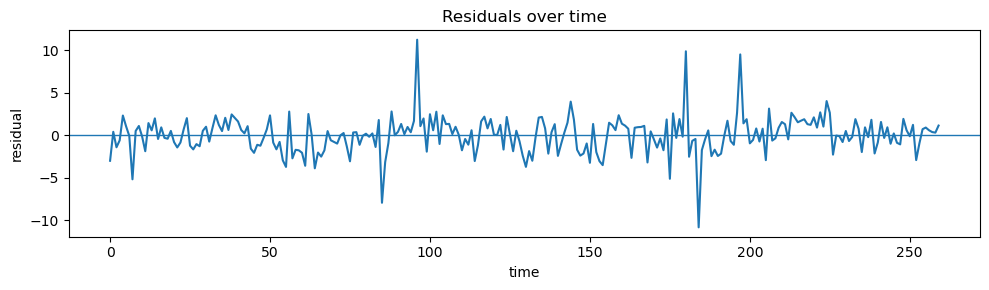

In [13]:
plt.figure(figsize=(10,3))
plt.plot(df["time"], residuals)
plt.axhline(0, linewidth=1)
plt.title("Residuals over time")
plt.xlabel("time")
plt.ylabel("residual")
plt.tight_layout()
plt.show()


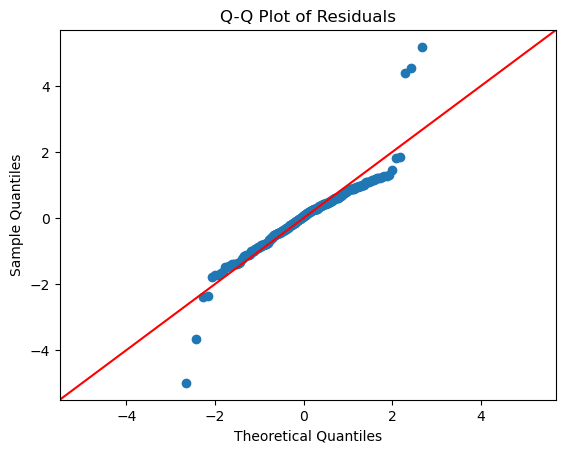

In [14]:
fig = sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [15]:
stat, p = normal_ad(residuals)

print(f"Anderson-Darling statistic: {stat:.4f}")
print(f"p-value: {p:.4e}")

if p < 0.05:
    print("Conclusion: Residuals are NOT normal (Reject H0)")
else:
    print("Conclusion: Residuals follow a normal distribution (Fail to reject H0)")


Anderson-Darling statistic: 3.0442
p-value: 1.1676e-07
Conclusion: Residuals are NOT normal (Reject H0)


In [16]:
X = sm.add_constant(df[["x1", "x2", "x3", "x4", "x5"]])

vif_data = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df = pd.DataFrame({
    "Variable": X.columns,
    "VIF": vif_data
})

print(vif_df)

  Variable       VIF
0    const  1.049975
1       x1  7.349102
2       x2  7.308473
3       x3  2.321787
4       x4  2.322354
5       x5  1.014170


In [17]:
vif_df.to_csv(OUT_DIR / "vif_baseline.csv", index=False)


In [18]:
infl = model.get_influence()
summary_frame = infl.summary_frame()

print(summary_frame.head())


   dfb_Intercept    dfb_x1    dfb_x2    dfb_x3    dfb_x4    dfb_x5   cooks_d  \
0      -0.081889 -0.005121 -0.003403  0.093739 -0.077049 -0.063980  0.003402   
1       0.013960 -0.008821  0.011736 -0.003259 -0.003199 -0.010818  0.000082   
2      -0.036961  0.021476 -0.023884 -0.020238  0.028053 -0.062610  0.001206   
3      -0.013870  0.007587 -0.003446  0.021365 -0.013054 -0.010566  0.000183   
4       0.056805  0.047722 -0.061071  0.079973 -0.066939 -0.022019  0.002700   

   standard_resid  hat_diag  dffits_internal  student_resid    dffits  
0       -1.377096  0.010649        -0.142868      -1.379542 -0.143121  
1        0.183052  0.014392         0.022120       0.182703  0.022078  
2       -0.652081  0.016733        -0.085067      -0.651342 -0.084970  
3       -0.277477  0.014033        -0.033103      -0.276973 -0.033043  
4        1.062495  0.014145         0.127271       1.062765  0.127303  


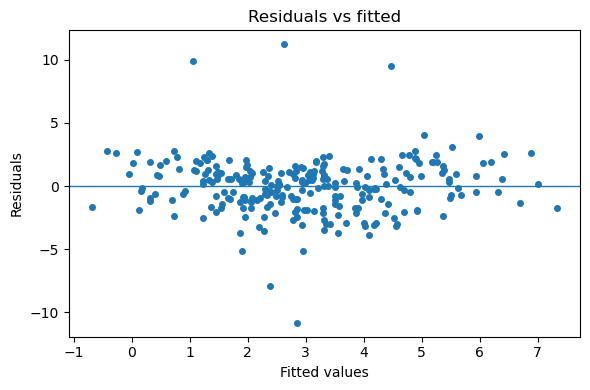

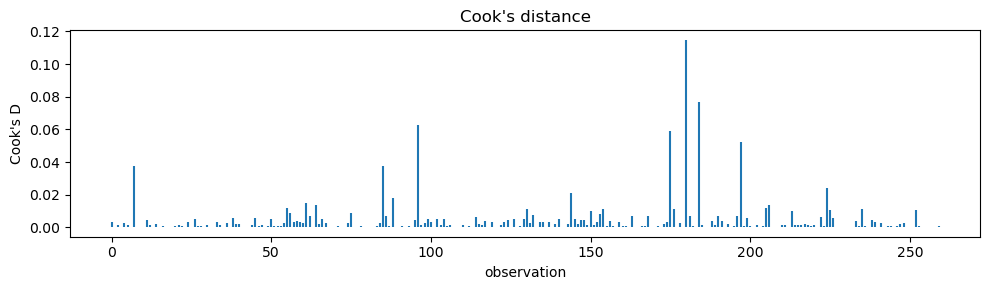

In [19]:
# Influence plots
# 1) Residuals vs fitted
plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals, s=16)
plt.axhline(0, linewidth=1)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted")
plt.tight_layout()
plt.show()

# 2) Cook's distance
cooks = summary_frame["cooks_d"]
plt.figure(figsize=(10,3))
plt.stem(np.arange(len(cooks)), cooks, markerfmt=" ", basefmt=" ")
plt.title("Cook's distance")
plt.xlabel("observation")
plt.ylabel("Cook's D")
plt.tight_layout()
plt.show()


In [20]:
n = len(df)
p = len(model.params)

leverage_threshold = 2 * p / n
cooks_threshold = 4 / n
studentized_threshold = 3

print(f"Thresholds: Leverage > {leverage_threshold:.4f}, Cook's D > {cooks_threshold:.4f}, |Student Resid| > {studentized_threshold}")

summary_frame['flag_outlier'] = np.abs(summary_frame['student_resid']) > studentized_threshold
summary_frame['flag_leverage'] = summary_frame['hat_diag'] > leverage_threshold
summary_frame['flag_cooks'] = summary_frame['cooks_d'] > cooks_threshold

flagged = summary_frame[
    summary_frame['flag_outlier'] | 
    summary_frame['flag_leverage'] | 
    summary_frame['flag_cooks']
].copy()

flagged.to_csv(OUT_DIR / "flagged_points.csv")

print(f"Number of flagged points: {len(flagged)}")
print("\nPreview of flagged points:")
print(flagged[['student_resid', 'hat_diag', 'cooks_d', 'flag_outlier', 'flag_leverage', 'flag_cooks']].head())


Thresholds: Leverage > 0.0462, Cook's D > 0.0154, |Student Resid| > 3
Number of flagged points: 14

Preview of flagged points:
    student_resid  hat_diag   cooks_d  flag_outlier  flag_leverage  flag_cooks
7       -2.431323  0.037285  0.037433         False          False        True
26      -0.778542  0.050299  0.005359         False           True       False
85      -3.743329  0.016511  0.037296          True          False        True
88       1.313625  0.059838  0.018253         False           True        True
96       5.435762  0.014015  0.062925          True          False        True


In [21]:
lm_stat, p_value, f_stat, f_p_value = het_breuschpagan(residuals, X)

print("Breusch-Pagan Test Results:")
print(f"Lagrange Multiplier statistic: {lm_stat:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"F-statistic: {f_stat:.4f}")
print(f"F p-value: {f_p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Heteroscedasticity detected (Variance is NOT constant).")
else:
    print("Conclusion: Homoscedasticity assumption holds (Variance is constant).")


Breusch-Pagan Test Results:
Lagrange Multiplier statistic: 3.4074
p-value: 6.3744e-01
F-statistic: 0.6746
F p-value: 6.4306e-01
Conclusion: Homoscedasticity assumption holds (Variance is constant).


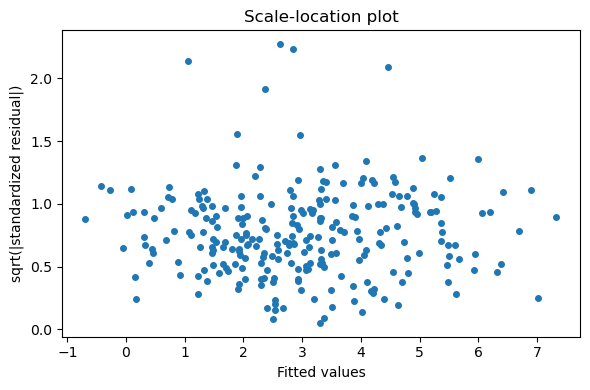

In [22]:
# Scale-location plot: sqrt(|standardized residuals|) vs fitted
std_resid = summary_frame["standard_resid"]
plt.figure(figsize=(6,4))
plt.scatter(fitted, np.sqrt(np.abs(std_resid)), s=16)
plt.xlabel("Fitted values")
plt.ylabel("sqrt(|standardized residual|)")
plt.title("Scale-location plot")
plt.tight_layout()
plt.show()


## Answer the following questions by interpreting the results and explaining the statistical concepts, assumptions, and implications of the methods used in this part. Avoid including code or raw outputs unless explicitly requested.

### 1. Based on the Q–Q plot and Anderson–Darling test, is the normality assumption satisfied?

### 2. Based on the VIF values, is multicollinearity a concern in this model?

### 3. What is the difference between an outlier and an influential observation?

### 1

خیر، فرض نرمال بودن خطاها **برقرار نیست**.
مقدار P-value در آزمون اندرسون-دارلینگ بسیار کمتر از ۰.۰۵ به دست آمد (حدود $10^{-7}$) که باعث رد فرض صفر می‌شود. همچنین در نمودار Q-Q، نقاط (به ویژه در ابتدا و انتها) از خط قرمز مرجع فاصله گرفته‌اند که نشان‌دهنده انحراف توزیع خطاها از توزیع نرمال استاندارد است.

### 2

خیر، هم‌خطی نگران‌کننده‌ای وجود ندارد.
مقادیر VIF برای تمام متغیرها پایین (کمتر از ۵) هستند و همچنین عدد وضعیت (Condition Number) مدل حدود ۵.۷ است که بسیار پایین می‌باشد. این نشان می‌دهد که متغیرهای مستقل همبستگی خطی شدیدی با یکدیگر ندارند و واریانس ضرایب به طور کاذب متورم نشده است.

### 3

- **داده پرت (Outlier):** مشاهده‌ای است که مقدار متغیر وابسته ($y$) آن با مقدار پیش‌بینی شده توسط مدل اختلاف زیادی دارد (باقی‌مانده یا Residual بزرگ)، اما لزوماً تأثیر شدیدی بر روی ضرایب خط رگرسیون نمی‌گذارد.
- **مشاهده اثرگذار (Influential Observation):** مشاهده‌ای است که حضور یا حذف آن، ضرایب مدل (شیب و عرض از مبدأ) را به شدت تغییر می‌دهد. این نقاط معمولاً ترکیبی از "داده پرت" و "مقدار اهرمی بالا" (High Leverage - مقدار $x$ غیرعادی) هستند.

## Part 6: Fix the model

# Fixes and improved model
### Apply at least TWO fixes, depending on diagnostics:
### - Add an interaction term (e.g., x3:x5)
### - Use log transform of y (if appropriate)
### - Remove or downweight influential points (document rule)
### - Use heteroskedasticity-robust standard errors
### - Use an interval-based guidance analogy? (Not needed here; stick to regression)

### Below, create an improved model and compare metrics and diagnostics before vs after.


In [23]:

indices_to_drop = flagged.index
df_clean = df.drop(index=indices_to_drop).copy()

improved_formula = "y ~ x1 + x2 + x3 + x5 + x3:x5"

improved = smf.ols(improved_formula, data=df_clean).fit()
print(improved.summary())

anova_imp = anova_lm(improved, typ=2)
anova_imp.to_csv(OUT_DIR / "anova_improved.csv")

df_clean['x3_x5'] = df_clean['x3'] * df_clean['x5']
X_imp = sm.add_constant(df_clean[['x1', 'x2', 'x3', 'x5', 'x3_x5']])

vif_data_imp = []
for i in range(X_imp.shape[1]):
    val = variance_inflation_factor(X_imp.values, i)
    vif_data_imp.append([X_imp.columns[i], val])

vif_improved = pd.DataFrame(vif_data_imp, columns=["Variable", "VIF"])
vif_improved.to_csv(OUT_DIR / "vif_improved.csv", index=False)

infl_imp = improved.get_influence()
summ_imp = infl_imp.summary_frame()

n_imp = len(df_clean)
p_imp = len(improved.params)
lev_thresh_imp = 2 * p_imp / n_imp
cooks_thresh_imp = 4 / n_imp

summ_imp['flag_outlier'] = np.abs(summ_imp['student_resid']) > 3
summ_imp['flag_leverage'] = summ_imp['hat_diag'] > lev_thresh_imp
summ_imp['flag_cooks'] = summ_imp['cooks_d'] > cooks_thresh_imp

flagged_improved = summ_imp[
    summ_imp['flag_outlier'] | summ_imp['flag_leverage'] | summ_imp['flag_cooks']
].copy()
flagged_improved.to_csv(OUT_DIR / "flagged_points_improved.csv")

comparison_data = {
    "Metric": ["R-squared", "Adj. R-squared", "AIC", "BIC", "F-statistic"],
    "Baseline": [model.rsquared, model.rsquared_adj, model.aic, model.bic, model.fvalue],
    "Improved": [improved.rsquared, improved.rsquared_adj, improved.aic, improved.bic, improved.fvalue]
}

summary_comparison = pd.DataFrame(comparison_data)
summary_comparison.to_csv(OUT_DIR / "summary_comparison.csv", index=False)

print("\n--- Model Comparison Table ---")
print(summary_comparison)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     83.13
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           2.16e-50
Time:                        14:45:21   Log-Likelihood:                -418.98
No. Observations:                 246   AIC:                             850.0
Df Residuals:                     240   BIC:                             871.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9840      0.088     33.963      0.0

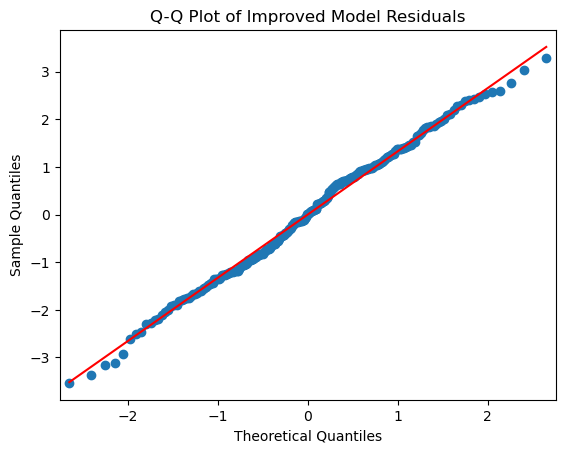

In [24]:
# Extra section added to visualize the improvement over the baseline model

# Q-Q plot for the IMPROVED model
# This shows if the residuals are now normal
residuals_improved = improved.resid
fig = sm.qqplot(residuals_improved, line="s") 
plt.title("Q-Q Plot of Improved Model Residuals")
plt.show()

## Answer the following questions by interpreting the results and explaining the statistical concepts, assumptions, and implications of the methods used in this part. Avoid including code or raw outputs unless explicitly requested.

### 1. Why is adding the interaction term x3:x5 a reasonable fix in this model?

### 2. The interaction term x3:x5 is highly significant in the improved model. What does this imply?

### 3. What are the potential risks of removing influential observations from a dataset?

### 4. Why might it be inappropriate or unnecessary to apply all possible fixes (e.g., transformation, robust SEs, removal of points) simultaneously?

### 5. If the main goal were prediction rather than inference, would all these fixes still be necessary? Explain.

### 1

افزودن ترم تعاملی ($x_3 \times x_5$) منطقی است زیرا فرض می‌کند که اثر متغیر $x_3$ بر روی $y$ ثابت نیست و به مقدار متغیر $x_5$ بستگی دارد (و بالعکس). جهش چشمگیر در مقدار $R^2$ (از ۰.۳۵ به ۰.۶۳) و کاهش شدید AIC پس از اضافه کردن این ترم، نشان می‌دهد که مدل خطی ساده (Additive) قادر به توضیح پیچیدگی داده‌ها نبوده و این تعامل واقعی در داده‌ها وجود داشته است.

### 2

معناداری بالای این ترم ($p \approx 0.000$) بدین معناست که شیب خط رگرسیون برای متغیر $x_3$ تابعی از $x_5$ است. به عبارت دیگر، ما نمی‌توانیم اثر $x_3$ را به صورت مستقل تفسیر کنیم؛ بلکه شدت تأثیر $x_3$ بر $y$ با تغییر سطح $x_5$ تغییر می‌کند (مثلاً ممکن است در مقادیر بالای $x_5$، اثر $x_3$ شدیدتر یا ضعیف‌تر شود).

### 3

حذف نقاط اثرگذار می‌تواند منجر به "بیش‌برازش" (Overfitting) شود، زیرا مدل بیش از حد به داده‌های نمونه‌ی خاص وابسته می‌شود و توانایی تعمیم به داده‌های جدید را از دست می‌دهد. همچنین، اگر این نقاط ناشی از خطای اندازه‌گیری نباشند و بخشی از واقعیت جامعه باشند، حذف آن‌ها باعث می‌شود مدل نهایی واریانس واقعی داده‌ها را دست‌کم بگیرد و برآوردهای اریب (Biased Estimates) ارائه دهد.

### 4

اعمال همزمان تمام اصلاحات بدون دلیل مشخص، "داده‌کاوی" (Data Dredging) محسوب می‌شود و تفسیر مدل را بسیار دشوار می‌کند. ممکن است برخی اصلاحات اثر یکدیگر را خنثی کنند یا با هم تداخل داشته باشند (مثلاً تبدیل لگاریتمی ممکن است مشکل ناهمسانی واریانس را حل کند و دیگر نیازی به حذف نقاط پرت نباشد). اصلاحات باید گام‌به‌گام و بر اساس شواهد دیاگنوستیک اعمال شوند.

### 5

خیر، لزوماً همه آن‌ها ضروری نیستند.
- در **استنباط (Inference)**، صحت فرضیات (مانند نرمال بودن خطاها و همسانی واریانس) برای اعتبار آزمون‌های آماری و فواصل اطمینان حیاتی است.
- اما در **پیش‌بینی (Prediction)**، هدف اصلی کاهش خطای پیش‌بینی (MSE) روی داده‌های جدید است. مدل‌های پیش‌بینی می‌توانند حتی با وجود نقض فرض نرمالیتی یا وجود هم‌خطی، عملکرد خوبی داشته باشند. البته حذف داده‌های پرت معمولاً در هر دو حالت به بهبود مدل کمک می‌کند.